In [69]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode ,tools_condition

from typing_extensions import TypedDict
from typing import Annotated
from rich import print
from langchain_mistralai import ChatMistralAI 
from langchain_tavily import TavilySearch
from dotenv import load_dotenv

In [56]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [57]:
load_dotenv()

True

In [58]:
llm=ChatMistralAI(model_name="mistral-small-latest")

In [59]:
# Create Tools (Pre Defined Tools)
tool=TavilySearch(max_results=1)

In [60]:
# Custom Functions
def multiply(x:int,y:int)->int:
    """
    Multiply x and y
    args:
    x (int):first int
    y(int):second int

    return (int): multiplication of x and y

    """
    return x*y

In [61]:
tools=[tool,multiply]

In [62]:
llm_tools=llm.bind_tools(tools)

In [63]:
def llm_with_tools(state:State):
    return {"messages":[llm_tools.invoke(state['messages'])]}

In [64]:
builder=StateGraph(State)
builder.add_node("llm_with_tools",llm_with_tools)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
     # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
graph=builder.compile()

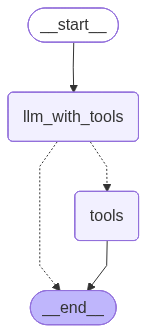

In [65]:
builder.compile()

In [66]:
response=graph.invoke({"messages":"Give me latest AI news"})

In [71]:
print(response["messages"])

[
    HumanMessage(
        content='Give me latest AI news',
        additional_kwargs={},
        response_metadata={},
        id='d87a3aa2-65ea-4c9e-a12d-a9a0c4c797ac'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'tool_calls': [
                {
                    'id': 'FNEIjjTTF',
                    'function': {
                        'name': 'tavily_search',
                        'arguments': '{"query": "latest AI news", "search_depth": "advanced", "topic": "news"}'
                    },
                    'index': 0
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'prompt_tokens': 1780,
                'total_tokens': 1808,
                'completion_tokens': 28,
                'prompt_tokens_details': {'cached_tokens': 0}
            },
            'model_name': 'mistral-small-latest',
            'model': 'mistral-small-latest',
            'finish_reason': 'tool_calls',
            'model_provider': 'mistralai'
        },
        id='lc_run--019e068d-5810-7480-bc6e-5b964aa69207-0',
        tool_calls=[
            {
                'name': 'tavily_search',
                'args': {'query': 'latest AI news', 'search_depth': 'advanced', 'topic': 'news'},
                'id': 'FNEIjjTTF',
                'type': 'tool_call'
            }
        ],
        invalid_tool_calls=[],
        usage_metadata={'input_tokens': 1780, 'output_tokens': 28, 'total_tokens': 1808}
    ),
    ToolMessage(
        content='{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": 
[{"url": 
"https://www.forbes.com/sites/davidphelan/2026/05/01/samsung-one-ui-85-update-missing-why-millions-of-galaxy-users-
are-still-waiting-today/", "title": "Samsung One UI 8.5 Update Missing: Why Galaxy Users Are Still Waiting Today - 
Forbes", "score": 0.87663436, "published_date": "Sat, 02 May 2026 08:00:00 GMT", "content": "“Beta testers also 
praise the software’s fluidity and stability, as compared to the One UI 8.0 software,” Sammyfans has said.\\n\\n1/1
Skip Ad Continue watching after the adImage 12: Loading PodsVisit Advertiser websiteGO TO PAGE\\n\\nThe Prompt: Get
the week’s biggest AI news on the buzziest companies and boldest breakthroughs, in your inbox.\\n\\nEmail Address 
\\n\\n Sign Up \\n\\nBy signing up, you agree to receive this newsletter, other updates about Forbes and its 
affiliates’ offerings, our Terms of Service (including resolving disputes on an individual basis via arbitration), 
and you acknowledge our Privacy Statement. Forbes is protected by reCAPTCHA, and the Google Privacy Policy and 
Terms of Service apply.\\n\\nYou’re Subscribed!\\n\\nExplore More Newsletters\\n\\nYou’re Subscribed!\\n\\nExplore 
More Newsletters", "raw_content": null}], "response_time": 0.92, "request_id": 
"01e55007-589b-4ffc-a341-485cdb72f6b3"}',
        name='tavily_search',
        id='1c33776b-a48f-4791-9eb2-3d232cbe27d3',
        tool_call_id='FNEIjjTTF'
    )
]

In [72]:
response2=graph.invoke({"messages":"2muliply5 then multiply with 10"})

In [74]:
print(response2["messages"][-1])

ToolMessage(content='100', name='multiply', id='7ef7a866-37c4-4c7d-84b1-88e172c6bc9f', tool_call_id='Mcv9aQQmp')

In [75]:
response3=graph.invoke({"messages":"Give latest news on NVDIA and multiply 2 with 5"})

In [77]:
print(response3["messages"])

[
    HumanMessage(
        content='Give latest news on NVDIA and multiply 2 with 5',
        additional_kwargs={},
        response_metadata={},
        id='fa95cd92-a5e3-4cba-96f6-f88006f95303'
    ),
    AIMessage(
        content='',
        additional_kwargs={
            'tool_calls': [
                {
                    'id': 'v2GCK9ue5',
                    'function': {
                        'name': 'tavily_search',
                        'arguments': '{"query": "latest news on NVIDIA", "search_depth": "advanced", "time_range": 
"day"}'
                    },
                    'index': 0
                },
                {
                    'id': 'sBLt9Htwq',
                    'function': {'name': 'multiply', 'arguments': '{"x": 2, "y": 5}'},
                    'index': 1
                }
            ]
        },
        response_metadata={
            'token_usage': {
                'prompt_tokens': 1789,
                'total_tokens': 1837,
                'completion_tokens': 48,
                'prompt_tokens_details': {'cached_tokens': 0}
            },
            'model_name': 'mistral-small-latest',
            'model': 'mistral-small-latest',
            'finish_reason': 'tool_calls',
            'model_provider': 'mistralai'
        },
        id='lc_run--019e0693-b51f-7b11-b9c3-f9aed7183af5-0',
        tool_calls=[
            {
                'name': 'tavily_search',
                'args': {'query': 'latest news on NVIDIA', 'search_depth': 'advanced', 'time_range': 'day'},
                'id': 'v2GCK9ue5',
                'type': 'tool_call'
            },
            {'name': 'multiply', 'args': {'x': 2, 'y': 5}, 'id': 'sBLt9Htwq', 'type': 'tool_call'}
        ],
        invalid_tool_calls=[],
        usage_metadata={'input_tokens': 1789, 'output_tokens': 48, 'total_tokens': 1837}
    ),
    ToolMessage(
        content='{"query": "latest news on NVIDIA", "follow_up_questions": null, "answer": null, "images": [], 
"results": [{"url": 
"https://nvidianews.nvidia.com/news/nvidia-and-iren-announce-strategic-partnership-to-accelerate-deployment-of-up-t
o-5-gigawatts-of-ai-infrastructure", "title": "NVIDIA and IREN Announce Strategic Partnership to Accelerate 
Deployment of up to 5 Gigawatts of AI Infrastructure | NVIDIA Newsroom", "content": "high performance computing 
solutions (including the market for cloud services and potential colocation services, along with other important 
factors discussed under the caption “Risk Factors” in IREN’s Annual Report on Form 10-K, filed with Securities and 
Exchange Commission (the “SEC”) on August 28, 2025 and our other filings with the SEC. These and other important 
factors could cause actual results to differ materially from those indicated by the forward-looking statements made
in this press release. Any forward-looking statement included in this press release speaks only as of the date of 
such statement. Except as required by law, IREN disclaims any obligation to update or revise, or to publicly 
announce any update or revision to, any of the forward-looking statements, whether as a [...] high performance 
computing solutions (including the market for cloud services and potential colocation services, along with other 
important factors discussed under the caption “Risk Factors” in IREN’s Annual Report on Form 10-K, filed with 
Securities and Exchange Commission (the “SEC”) on August 28, 2025 and our other filings with the SEC. These and 
other important factors could cause actual results to differ materially from those indicated by the forward-looking
statements made in this press release. Any forward-looking statement included in this press release speaks only as 
of the date of such statement. Except as required by law, IREN disclaims any obligation to update or revise, or to 
publicly announce any update or revision to, any of the forward-looking statements, whether as a [...] This news 
release contains “forward-looking statements” within 

> Here in the last message we get 10 but the report reamin in another tool message so to solve it we can use ReactAgent

> Simple Instade of tool->END redirect back to llm_with tools

In [ ]:
# Simple Instade of tool->END redirect back to llm_with tools

In [78]:
builder=StateGraph(State)
builder.add_node("llm_with_tools",llm_with_tools)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
     # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","llm_with_tools")
graph=builder.compile()

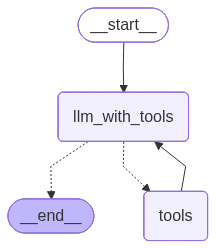

In [79]:
builder.compile()

In [80]:
response3=graph.invoke({"messages":"Give latest news on NVDIA and multiply 2 with 5"})

In [89]:
print(response3["messages"][-1])

AIMessage(
    content='### Latest News on NVIDIA\n\n**NVIDIA and IREN Announce Strategic Partnership to Accelerate Deployment
of up to 5 Gigawatts of AI Infrastructure**\n- **Date:** May 7, 2026\n- **Summary:** NVIDIA (NASDAQ: NVDA) and IREN
Limited (NASDAQ: IREN) have partnered to accelerate the deployment of next-generation AI infrastructure. The 
collaboration aims to deploy **up to 5 gigawatts** of AI infrastructure, marking a significant step in scaling AI 
capabilities globally.\n- **Source:** [NVIDIA 
Newsroom](https://nvidianews.nvidia.com/news/nvidia-and-iren-announce-strategic-partnership-to-accelerate-deploymen
t-of-up-to-5-gigawatts-of-ai-infrastructure)\n\n---\n\n### Calculation\nThe result of multiplying **2** and **5** 
is:\n**10**',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 2515,
            'total_tokens': 2718,
            'completion_tokens': 203,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-latest',
        'model': 'mistral-small-latest',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019e0699-ea29-71b2-b213-93a1a4ef169d-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 2515, 'output_tokens': 203, 'total_tokens': 2718}
)